In [1]:
# imports
import os
import sys
sys.path.append("../")
sys.path.append("../Modules/")
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np
# import generic morphology plotting function
from Modules import plot_morphology
from Modules import analysis
# import reading seg data function
# there isn't one? we just read the csv file using pandas.


real seg data

In [64]:
# sim_directory = '/home/drfrbc/Neural-Modeling/scripts/2024-12-23-15-23-44-BenSynapses_final_detailed_syn_dist_analysis/Complex_InhGmaxApic7.1_InhGmaxDend0.0016_SomaGmax0.0025_ExcGmax-1.0351_Np1000'
sim_directory = "/home/drfrbc/Neural-Modeling/cells/segment_info/L5PC_medium_seg_res"

In [65]:
# read seg data
seg_data = pd.read_csv(os.path.join(sim_directory, "segment_data.csv"))

# # read synapses
# syn_data = read_synapse_distribution_file(sim_directory)
# # read transfer impedances
# imp_df = read_transfer_impedance_file(sim_directory, loc='soma')
# seg_data['soma_trans_imp'] = imp_df.beta_active

In [98]:
for i,seg in seg_data.iterrows():
    print(seg.seg)
    if i == 0:
        break

L5PCtemplate[0].soma[0](0.5)


example data (to be replaced later)

In [ ]:
# example data (to be replaced later)
location_types_by_synapse_type = {
    'inhPerisomatic': ['perisomatic'],
    'exc': ['distal_basal', 'distal_apic'],
    'inhDendritic': ['distal_basal', 'distal_apic']
}

segments = [seg.seg for i,seg in seg_data.iterrows()]#[seg for sec in synapses['exc'].cell.all for seg in sec]
results = []
resulting_PSCs_by_segment = {}
for synapse_type in location_types_by_synapse_type.keys():
  resulting_PSCs_by_segment[synapse_type] = {} # make 1 for each tuner/synapse type
  resulting_PSCs_by_segment[synapse_type]['segments'] = segments#[seg for sec in synapses[synapse_type].cell.all for seg in sec] # list segments for each tuner Segments are the same, but identified differently bc each tuner built its own cell.
  for location_type in location_types_by_synapse_type[synapse_type]: # make one for each location type
    resulting_PSCs_by_segment[synapse_type][location_type] = [[0] for seg in resulting_PSCs_by_segment[synapse_type]['segments']] # initialize list of PSCs that were used for each segment
    for i, seg in enumerate(resulting_PSCs_by_segment[synapse_type]['segments']):
      if resulting_PSCs_by_segment[synapse_type][location_type][i] == []: # if there are no PSCs for this segment, initialize it to 0
        resulting_PSCs_by_segment[synapse_type][location_type][i] = [0]

In [ ]:
# Load real data from a file
import pickle
with open('resulting_PSCs_by_segment.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

In [78]:
def plot_PSCs_on_morphology(resulting_PSCs_by_segment, seg_data, synapse_type_to_plot, data_to_plot_name, clim_max=30):
    location_types = []
    synapse_types = []
    titles = []
    for synapse_type in location_types_by_synapse_type.keys():
        if synapse_type_to_plot in synapse_type:
            for location_type in location_types_by_synapse_type[synapse_type]:
                location_types.append(location_type)
                synapse_types.append(synapse_type)
                titles.append(f'{synapse_type} {location_type}')
                if data_to_plot_name == 'PSC_mean':
                    data_to_plot = [np.mean(resulting_PSCs_by_segment[synapse_type][location_type][seg_id]) for seg_id in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))]
                elif data_to_plot_name == 'PSC_std':
                    data_to_plot = [np.std(resulting_PSCs_by_segment[synapse_type][location_type][seg_id]) for seg_id in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))]
                else:
                    raise NotImplementedError(f'{data_to_plot_name}')

    fig, axes = plt.subplots(1, len(titles), figsize=(16, 8), subplot_kw={'projection': '3d'})
    # Ensure axes is always a list
    if len(titles) == 1:
        axes = [axes]

    for ax, synapse_type, location_type, title in zip(axes, synapse_types, location_types, titles):
        plot_morphology.plot(seg_data, data_to_plot, ax, title=title)
        # plot(seg_data, seg_id_column, variable_dict, ax, elevation=20, azimuth=-100, radius_scale=1.0, title='', clim_max=30)

    # Fix colorbar for global scaling
    norm = plt.Normalize(vmin=0, vmax=clim_max)
    mappable = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
    plt.colorbar(mappable, ax=axes, shrink=0.6, label=data_to_plot_name, pad =-0.25)
    plt.tight_layout()
    plt.show()

In [83]:
def plot_PSC_mean_std_on_morphology(resulting_PSCs_by_segment, seg_data, synapse_type_to_plot, data_to_plot_name, clim_max=30):
    location_types = []
    synapse_types = []
    titles = []
    datas_to_plot = []
    for synapse_type in location_types_by_synapse_type.keys():
        if synapse_type_to_plot in synapse_type:
            for location_type in location_types_by_synapse_type[synapse_type]:
                for data_to_plot_name in ['PSC_mean', 'PSC_std']:
                    location_types.append(location_type)
                    synapse_types.append(synapse_type)
                    titles.append(f'{synapse_type} {location_type} {data_to_plot_name}')
                    if data_to_plot_name == 'PSC_mean':
                        datas_to_plot.append([np.mean(resulting_PSCs_by_segment[synapse_type][location_type][seg_id]) for seg_id in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))])
                    elif data_to_plot_name == 'PSC_std':
                        datas_to_plot.append([np.std(resulting_PSCs_by_segment[synapse_type][location_type][seg_id]) for seg_id in range(len(resulting_PSCs_by_segment[synapse_type][location_type]))])
                    else:
                        raise NotImplementedError(f'{data_to_plot_name}')
                    


    fig, axes = plt.subplots(int(len(titles)/2), 2, figsize=(16, 8), subplot_kw={'projection': '3d'})
    # Ensure axes is always a list
    if len(titles) == 1:
        axes = [axes]

    for ax, synapse_type, location_type, title, data_to_plot in zip(axes, synapse_types, location_types, titles, datas_to_plot):
        plot_morphology.plot(seg_data, data_to_plot, ax, title=title)

    # Fix colorbar for global scaling
    norm = plt.Normalize(vmin=0, vmax=clim_max)
    mappable = plt.cm.ScalarMappable(norm=norm, cmap='viridis')
    plt.colorbar(mappable, ax=axes, shrink=0.6, label=data_to_plot_name, pad =-0.25)
    plt.tight_layout()
    plt.show()

## inh perisomatic synapses

/tmp/ipykernel_2111097/3958870841.py:31: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


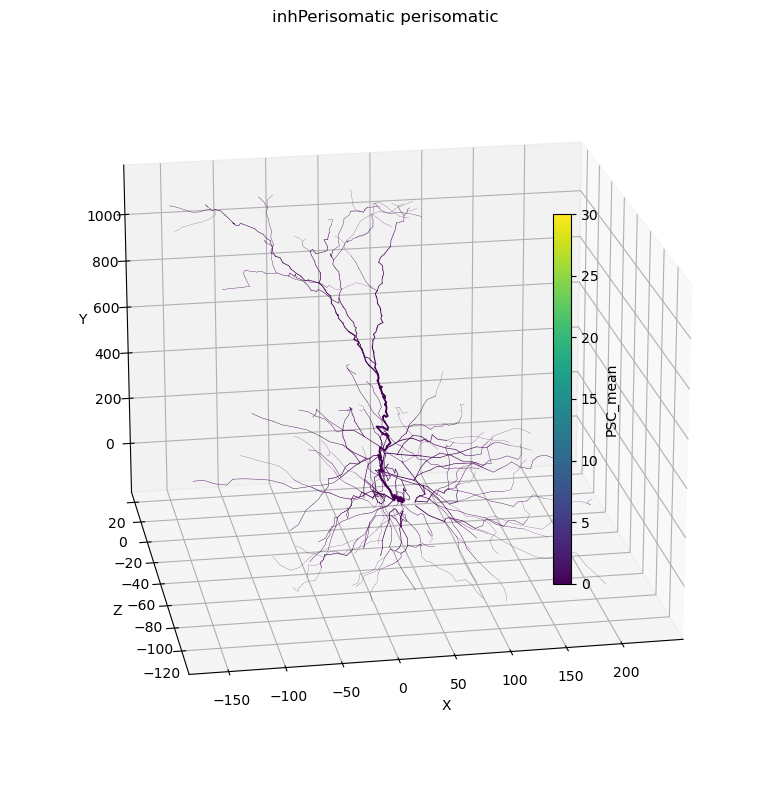

In [79]:
data_to_plot_name = 'PSC_mean'
synapse_type_to_plot = 'inhPerisomatic'
clim_max=30
plot_PSCs_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
                        seg_data=seg_data,
                        synapse_type_to_plot=synapse_type_to_plot,
                        data_to_plot_name=data_to_plot_name,
                        clim_max=clim_max)

/tmp/ipykernel_2111097/4249153151.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


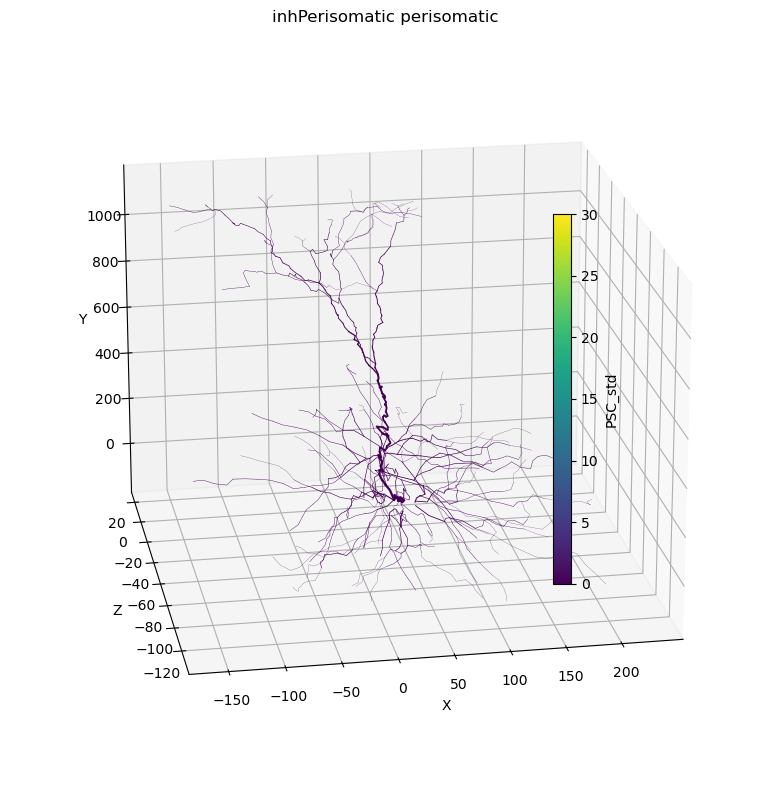

In [75]:
data_to_plot_name = 'PSC_std'
synapse_type_to_plot = 'inhPerisomatic'
clim_max=30
plot_PSCs_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
                        seg_data=seg_data,
                        synapse_type_to_plot=synapse_type_to_plot,
                        data_to_plot_name=data_to_plot_name,
                        clim_max=clim_max)

/tmp/ipykernel_2111097/722888245.py:34: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


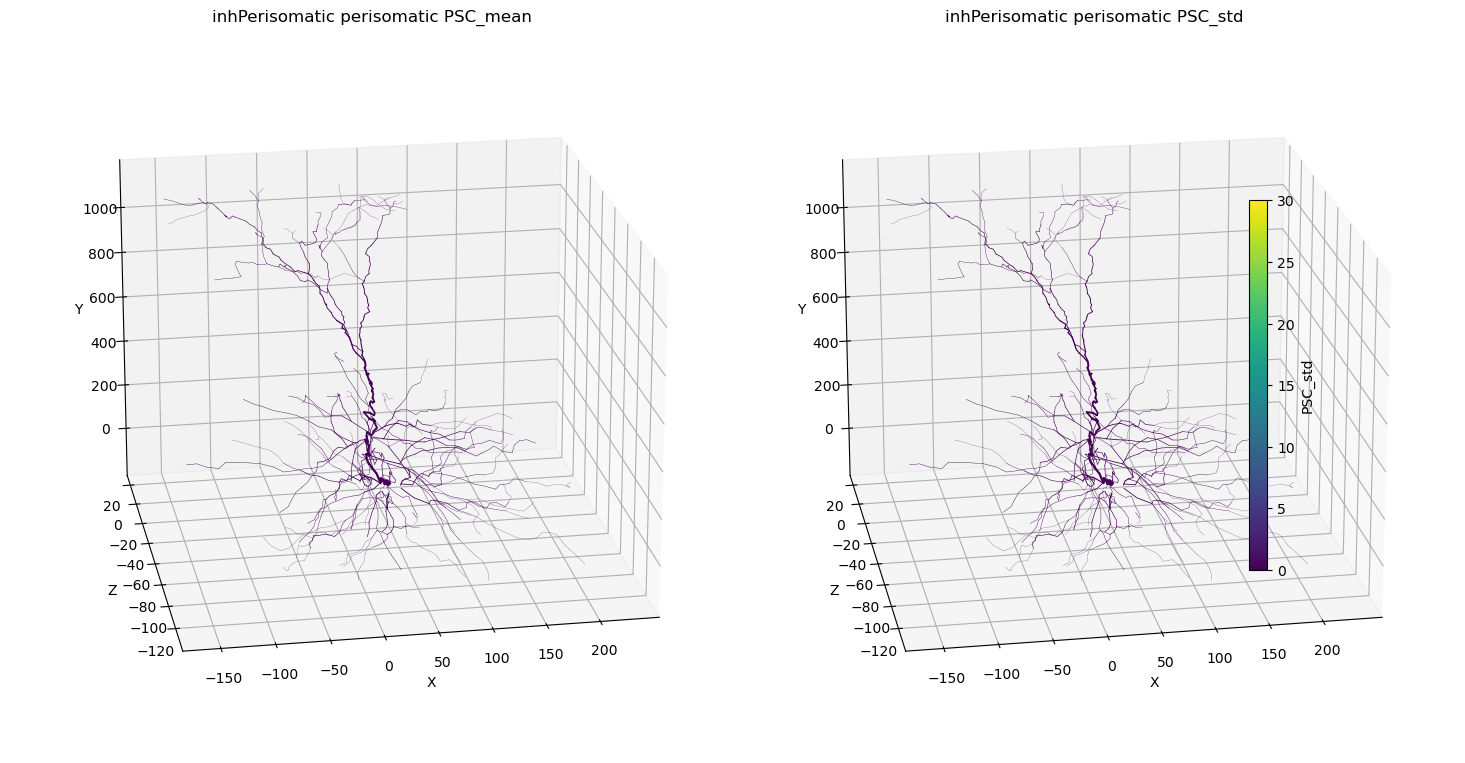

In [84]:
# testing plot psc mean and std together
data_to_plot_name = 'PSC_mean'
synapse_type_to_plot = 'inhPerisomatic'
clim_max=30
plot_PSC_mean_std_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
                        seg_data=seg_data,
                        synapse_type_to_plot=synapse_type_to_plot,
                        data_to_plot_name=data_to_plot_name,
                        clim_max=clim_max)

## inh distal synapses

/tmp/ipykernel_2111097/4249153151.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


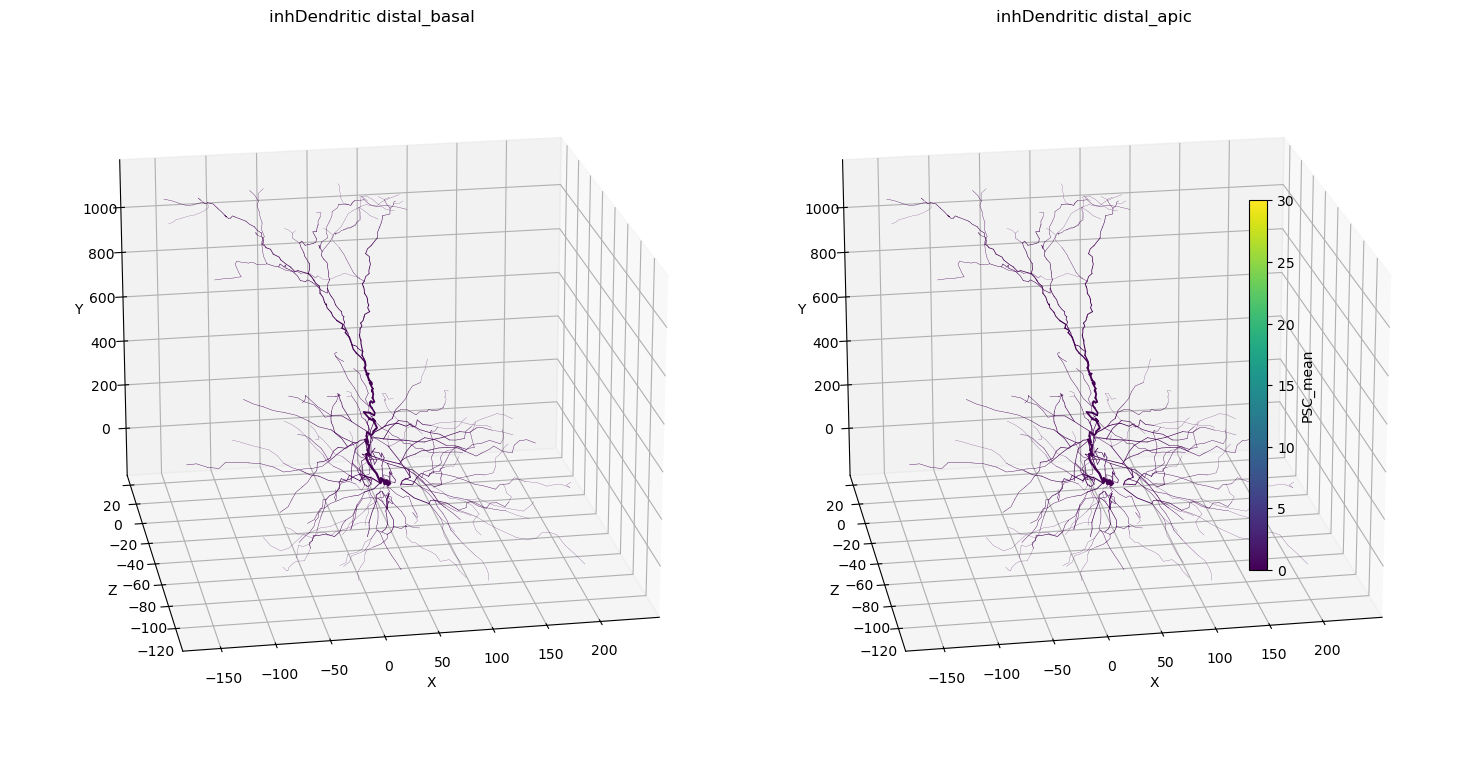

In [76]:
data_to_plot_name = 'PSC_mean'
synapse_type_to_plot = 'inhDendritic'
clim_max=30
plot_PSCs_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
                        seg_data=seg_data,
                        synapse_type_to_plot=synapse_type_to_plot,
                        data_to_plot_name=data_to_plot_name,
                        clim_max=clim_max)

## exc distal synapses

/tmp/ipykernel_2111097/4249153151.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


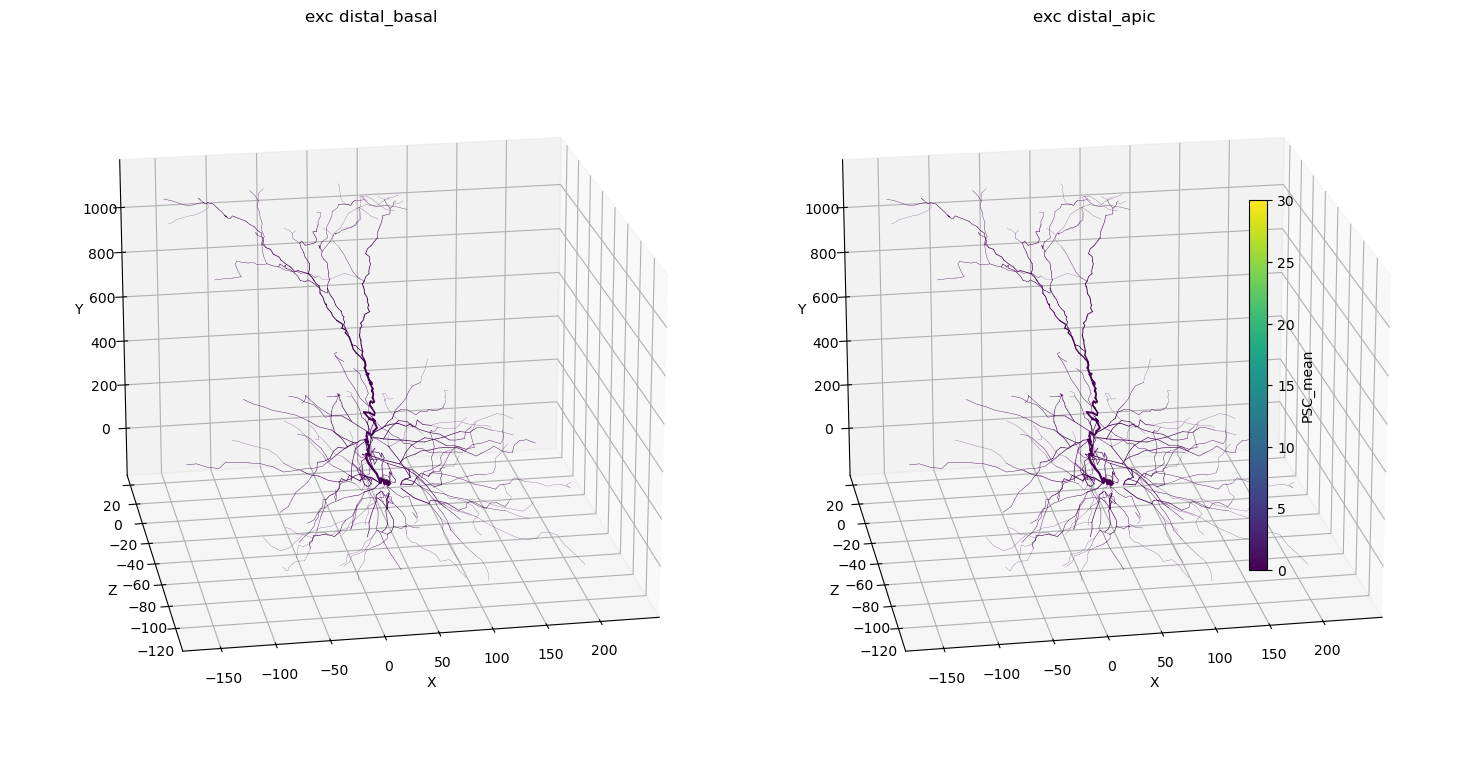

In [77]:
data_to_plot_name = 'PSC_mean'
synapse_type_to_plot = 'exc'
clim_max=30
plot_PSCs_on_morphology(resulting_PSCs_by_segment=resulting_PSCs_by_segment,
                        seg_data=seg_data,
                        synapse_type_to_plot=synapse_type_to_plot,
                        data_to_plot_name=data_to_plot_name,
                        clim_max=clim_max)